## 1. Setup and Environment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, 
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve
)

%matplotlib inline
sns.set_theme(style="whitegrid")

### Generate or Load Dataset
We use the synthetic but highly realistic `customer_data.csv`.

In [6]:
csv_path = 'customer_data.csv'
if not os.path.exists(csv_path):
    print("Generating synthetic dataset...")
    from generate_data import create_synthetic_data
    create_synthetic_data()
else:
    print("Dataset already exists.")

df = pd.read_csv(csv_path)
df.head()

Dataset already exists.


,CustomerID,Age,Gender,Tenure,MonthlyCharges,TotalCharges,ContractType,Churn
0,0001-XYZ,56,Male,11,87.41,948.00,Month-to-month,1
1,0002-XYZ,69,Male,31,45.99,1455.39,One year,1
2,0003-XYZ,46,Female,15,54.52,762.58,Month-to-month,1
3,0004-XYZ,32,Male,16,111.75,1834.20,Month-to-month,0
4,0005-XYZ,60,Male,7,49.05,318.24,Month-to-month,1


## 2. Preprocessing & Data Cleaning

In [7]:
print("Shape of dataset:", df.shape)
print("\nMissing values count:")
print(df.isnull().sum())

Shape of dataset: (1000, 8)

Missing values count:
CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
TotalCharges      30
ContractType       0
Churn              0
dtype: int64


### Convert types and handle missing data
We cast `TotalCharges` to numeric, and impute any missing values using the median value.

In [8]:
# Convert columns if necessary
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute with median
median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
TotalCharges      0
ContractType      0
Churn             0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

In [9]:
df.describe(include='all')

,CustomerID,Age,Gender,Tenure,MonthlyCharges,TotalCharges,ContractType,Churn
count,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,1000,NaN,2,NaN,NaN,NaN,3,NaN
top,0001-XYZ,NaN,Male,NaN,NaN,NaN,Month-to-month,NaN
freq,1,NaN,523,NaN,NaN,NaN,497,NaN
mean,NaN,49.857000,NaN,25.101000,69.920130,1729.560090,NaN,0.623000
std,NaN,18.114267,NaN,17.617468,28.904416,1508.284292,NaN,0.484877
min,NaN,18.000000,NaN,1.000000,20.000000,20.000000,NaN,0.000000
25%,NaN,35.000000,NaN,12.000000,44.715000,631.357500,NaN,0.000000
50%,NaN,50.000000,NaN,20.000000,70.140000,1245.690000,NaN,1.000000
75%,NaN,66.000000,NaN,37.000000,95.042500,2305.780000,NaN,1.000000


### EDA Plot 1: Histogram of Customer Age

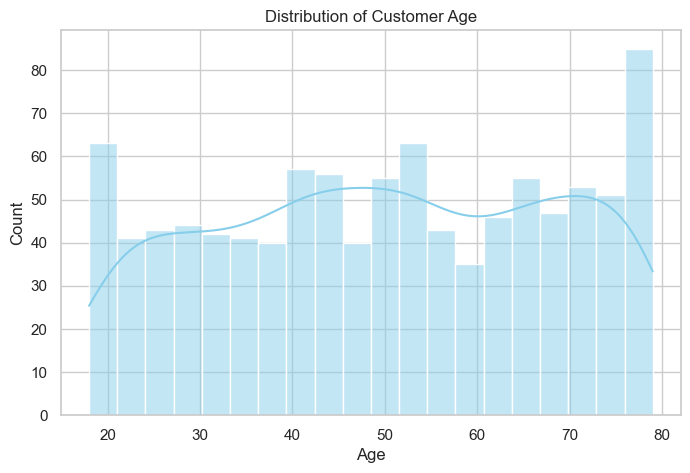

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### EDA Plot 2: Boxplot of Tenure by Churn Status

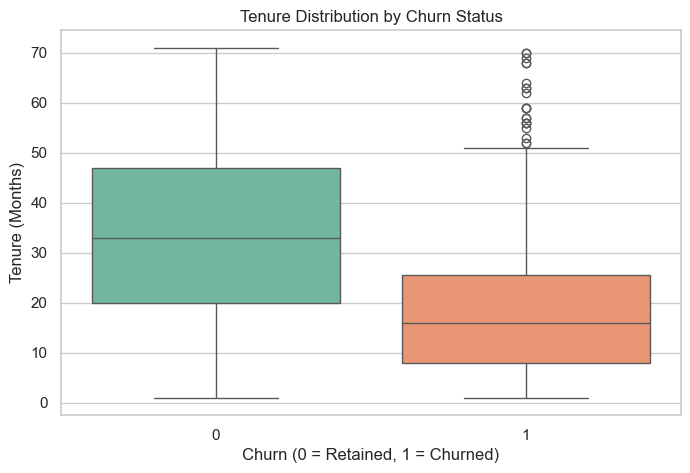

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Tenure', hue='Churn', data=df, palette='Set2', legend=False)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Tenure (Months)')
plt.show()

### EDA Plot 3: Scatter Plot of Monthly Charges vs. Total Charges

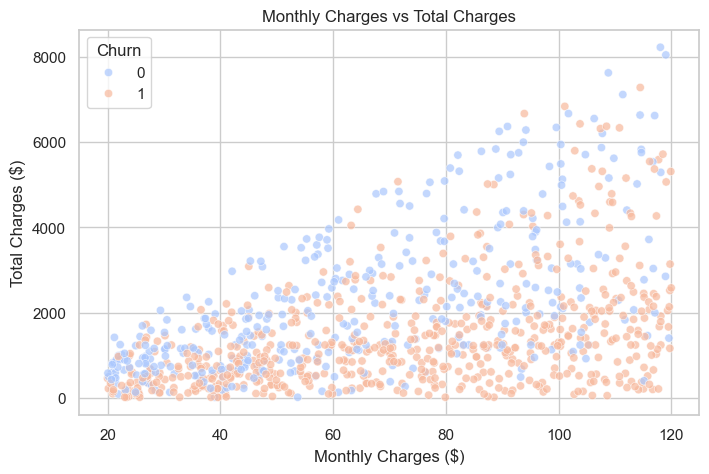

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, alpha=0.7, palette='coolwarm')
plt.title('Monthly Charges vs Total Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Total Charges ($)')
plt.show()

### EDA Plot 4: Bar Chart of Contract Type Count

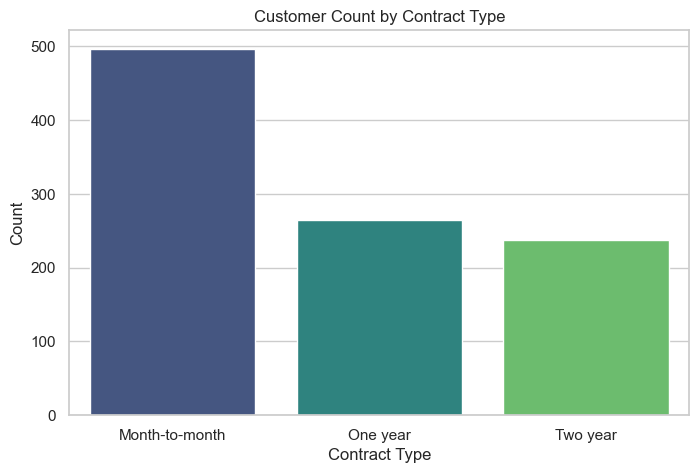

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='ContractType', hue='ContractType', data=df, palette='viridis', legend=False)
plt.title('Customer Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

## 4. Simple Linear Regression

In [14]:
# Using MonthlyCharges to predict TotalCharges
X_reg = df[['MonthlyCharges']]
y_reg = df['TotalCharges']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f"Linear Regression Evaluation:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Intercept: {reg_model.intercept_:.2f}")
print(f"Slope Coefficient: {reg_model.coef_[0]:.2f}")

Linear Regression Evaluation:
Mean Absolute Error (MAE): $932.04
Root Mean Squared Error (RMSE): $1247.46
Intercept: 10.88
Slope Coefficient: 25.27


## 5. Supervised Classification (Churn Prediction)
Here we compare **Logistic Regression** and a **Random Forest Classifier** to predict customer `Churn`.

In [18]:
# Encode categorical columns
df_encoded = pd.get_dummies(df.drop(columns=['CustomerID']), columns=['ContractType', 'Gender'], drop_first=True)

X_clf = df_encoded.drop(columns=['Churn'])
y_clf = df_encoded['Churn']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Instantiate
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
lr.fit(X_train_clf, y_train_clf)
rf.fit(X_train_clf, y_train_clf)

# Predictions
y_pred_lr = lr.predict(X_test_clf)
y_prob_lr = lr.predict_proba(X_test_clf)[:, 1]

y_pred_rf = rf.predict(X_test_clf)
y_prob_rf = rf.predict_proba(X_test_clf)[:, 1]

### Classification Model Evaluation Comparison

In [16]:
cv_lr = cross_val_score(lr, X_clf, y_clf, cv=5, scoring='accuracy').mean()
cv_rf = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='accuracy').mean()

metrics = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test_clf, y_pred_lr),
        "Precision": precision_score(y_test_clf, y_pred_lr),
        "Recall": recall_score(y_test_clf, y_pred_lr),
        "F1-Score": f1_score(y_test_clf, y_pred_lr),
        "ROC-AUC": roc_auc_score(y_test_clf, y_prob_lr),
        "5-Fold CV Accuracy": cv_lr
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test_clf, y_pred_rf),
        "Precision": precision_score(y_test_clf, y_pred_rf),
        "Recall": recall_score(y_test_clf, y_pred_rf),
        "F1-Score": f1_score(y_test_clf, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test_clf, y_prob_rf),
        "5-Fold CV Accuracy": cv_rf
    }
}

metrics_df = pd.DataFrame(metrics).T
metrics_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,5-Fold CV Accuracy
Logistic Regression,0.765,0.7945,0.8722,0.8315,0.8033,0.707
Random Forest,0.730,0.7883,0.8120,0.8000,0.7481,0.690


### Plot ROC Curves

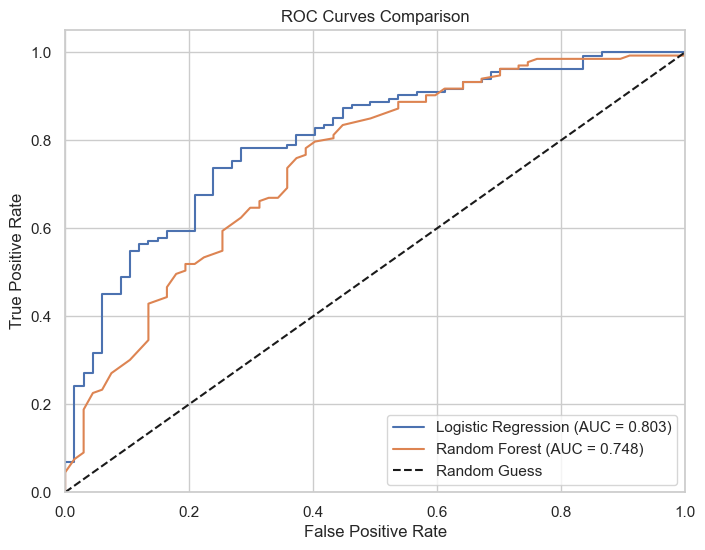

In [17]:
plt.figure(figsize=(8, 6))
for name, prob in [("Logistic Regression", y_prob_lr), ("Random Forest", y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test_clf, prob)
    auc_val = roc_auc_score(y_test_clf, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()